## Preparação

In [1]:
# Conecta o colab ao drive
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Importa as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

In [3]:
path_gold = "/content/drive/MyDrive/Colab Notebooks/dadosfera/amazon_products_gold_dashboard"

df = pd.read_parquet(path_gold, engine="pyarrow")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1379629 entries, 0 to 1379628
Data columns (total 25 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   product_id             1379629 non-null  object 
 1   product_title          1379629 non-null  string 
 2   category_id            1379629 non-null  int32  
 3   category_name          1379629 non-null  string 
 4   price                  1379629 non-null  float32
 5   list_price             1379629 non-null  float32
 6   rating                 1379629 non-null  float32
 7   review_count           1379629 non-null  int32  
 8   has_rating             1379629 non-null  bool   
 9   weighted_score         1379629 non-null  float32
 10  units_sold_last_month  1379629 non-null  int32  
 11  is_best_seller         1379629 non-null  bool   
 12  has_title              1379629 non-null  bool   
 13  image_url              1379629 non-null  string 
 14  product_url       

In [5]:
df.head(3)

,product_id,product_title,category_id,category_name,price,list_price,rating,review_count,has_rating,weighted_score,...,price_segment,popularity_tier,llm_brand_guess,llm_product_type,llm_attributes_json,llm_keywords_json,llm_title_clean,llm_model,created_at_utc,llm_error
0,B01M3RYHP0,Men's Tag-Free Cotton Briefs,110,Men's Clothing,8.38,22.99,4.6,0,True,0.0,...,budget,high,None,None,None,None,None,None,None,None
1,B07P7M18C6,Energy Unisex Easy-On/Easy-Off Knee High Compr...,110,Men's Clothing,11.88,0.00,4.3,0,True,0.0,...,budget,high,None,None,None,None,None,None,None,None
2,B0B62HGK2H,Hooded Rain Poncho Waterproof Raincoat Jacket ...,110,Men's Clothing,9.99,13.99,4.5,0,True,0.0,...,budget,high,None,None,None,None,None,None,None,None


In [6]:
df.isna().mean().sort_values(ascending=False).head(10)

,0
llm_error,1.000000
llm_brand_guess,0.999879
llm_title_clean,0.999710
llm_keywords_json,0.999710
llm_product_type,0.999710
llm_model,0.999710
created_at_utc,0.999710
llm_attributes_json,0.999710
product_id,0.000000
has_rating,0.000000


## Dashboard Power BI Dataframes

### Pré-processamento

In [7]:
# Normalizar strings
for c in ["category_name", "price_segment", "popularity_tier", "llm_brand_guess", "llm_product_type"]:
    if c in df.columns:
        df[c] = df[c].astype("string").str.strip()

In [8]:
# Filtrar brands vazias
df["llm_brand_guess"] = df["llm_brand_guess"].replace({"": pd.NA, "None": pd.NA})
df["llm_product_type"] = df["llm_product_type"].replace({"": pd.NA, "None": pd.NA})

### Pré-visualizações

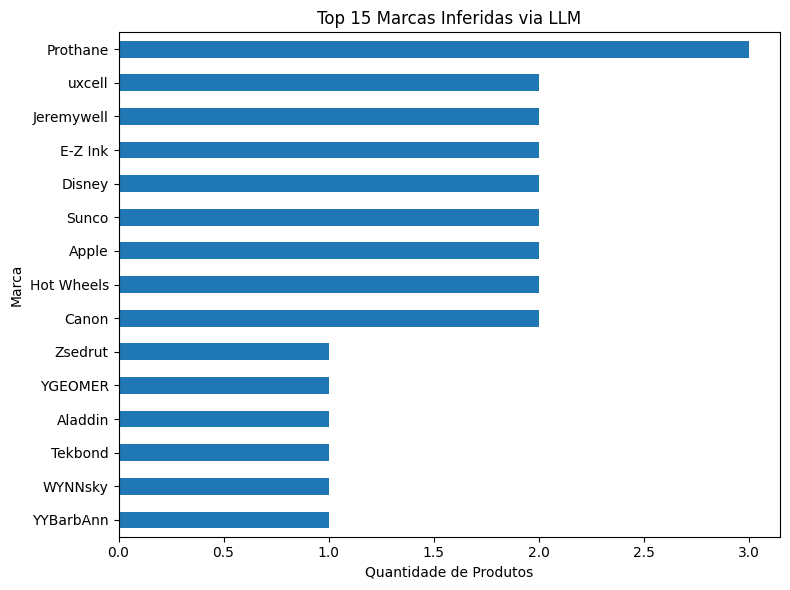

In [9]:
# Top 15 Marcas Inferidas via LLM
top_brands = df["llm_brand_guess"].dropna().value_counts().head(15)

plt.figure(figsize=(8,6))
top_brands.sort_values().plot(kind="barh")
plt.title("Top 15 Marcas Inferidas via LLM")
plt.xlabel("Quantidade de Produtos")
plt.ylabel("Marca")
plt.tight_layout()

plt.show()

In [10]:
# Overview por categoria
cat_overview = (
    df.groupby(["category_id", "category_name"], dropna=False)
      .agg(
          products=("product_id", "count"),
          best_sellers=("is_best_seller", "sum"),
          avg_price=("price", "mean"),
          median_price=("price", "median"),
          avg_rating=("rating", "mean"),
          rated_products=("has_rating", "sum"),
          pct_rated=("has_rating", "mean"),
      )
      .reset_index()
)

cat_overview.head()

,category_id,category_name,products,best_sellers,avg_price,median_price,avg_rating,rated_products,pct_rated
0,1,Beading & Jewelry Making,8229,26,14.034677,9.99,4.371941,8012,0.973630
1,2,Fabric Decorating,2005,3,18.262779,11.99,3.433317,1591,0.793516
2,3,Knitting & Crochet Supplies,8143,12,17.136339,12.99,4.076692,7408,0.909738
3,4,Printmaking Supplies,5347,11,54.780857,22.26,3.429044,4244,0.793716
4,5,Scrapbooking & Stamping Supplies,5886,22,14.912978,9.99,4.374482,5692,0.967040


In [11]:
# Heatmap-table por categoria x price_segment x popularity_tier
cat_segment_tier = (
    df.groupby(["category_name", "price_segment", "popularity_tier"], dropna=False)
      .agg(
          products=("product_id", "count"),
          revenue_proxy=("price", "sum"),
          avg_price=("price", "mean"),
          avg_rating=("rating", "mean"),
      )
      .reset_index()
)

cat_segment_tier.head()

,category_name,price_segment,popularity_tier,products,revenue_proxy,avg_price,avg_rating
0,Abrasive & Finishing Products,budget,high,532,4711.009766,8.855282,4.420301
1,Abrasive & Finishing Products,budget,medium,2650,22734.259766,8.578966,3.165246
2,Abrasive & Finishing Products,luxury,high,79,4055.760010,51.338734,4.502532
3,Abrasive & Finishing Products,luxury,medium,1173,90401.007812,77.068207,3.379028
4,Abrasive & Finishing Products,mid,high,459,7288.140137,15.878301,4.482789


In [12]:
# Top product types por volume
top_types = (
    df["llm_product_type"]
    .dropna()
    .value_counts()
    .head(30)
    .rename_axis("llm_product_type")
    .reset_index(name="products")
)

top_types.head()

,llm_product_type,products
0,headphones,9
1,watch,8
2,decoração,8
3,backpack,7
4,toys,7


In [13]:
# Top 1 produto por categoria (mais vendido no último mês)
top_prod_by_cat = (
    df.sort_values(["category_id", "units_sold_last_month", "weighted_score"], ascending=[True, False, False])
      .groupby("category_id", as_index=False)
      .head(1)
      [["category_id", "product_title", "units_sold_last_month", "price", "rating"]]
)

top_prod_by_cat.head()

,category_id,product_title,units_sold_last_month,price,rating
71118,1,Paxcoo 1mm Elastic Bracelet String Cord Stretc...,20000,6.990000,4.4
692045,2,"Tulip One-Step Tie-Dye Party, 18 Pre-Filled Bo...",3000,19.340000,4.8
99845,3,"WikkiStix Sensory Fidget Toy, Arts and Crafts ...",9000,7.160000,4.3
1074848,4,Godora DTF Powder White Digital Transfer Hot M...,3000,20.879999,4.6
134188,5,"Personalized Name Stamp for Kids Clothing, Cus...",5000,6.980000,4.3


In [14]:
# AI Product Intelligence & Strategic Positioning
df_ai_segment = (
    df
    .groupby(["llm_product_type", "price_segment", "popularity_tier", "llm_brand_guess", "llm_title_clean"])
    .agg(
        products=("product_id", "count"),
        avg_price=("price", "mean"),
        avg_rating=("rating", "mean"),
        total_units=("units_sold_last_month", "sum")
    )
    .reset_index()
)

df_ai_segment.head()

,llm_product_type,price_segment,popularity_tier,llm_brand_guess,llm_title_clean,products,avg_price,avg_rating,total_units
0,LED Bulbs,premium,high,Hikari,Hikari 2023 20000LM H11 H8 H9 LED Bulbs,1,31.98,4.8,500
1,LED Bulbs,premium,high,Sunco,Sunco 10 Pack BR30 LED Bulbs Indoor Flood Lights,1,27.99,4.6,100
2,LED Bulbs,premium,medium,Sunco,Sunco 10 Pack BR30 LED Bulbs Indoor Flood Lights,1,27.99,4.6,50
3,LED bulb,mid,high,SYLVANIA,SYLVANIA 4114 ZEVO LED White Bulb,1,19.75,4.6,200
4,MP3 Player,luxury,high,FINIS,FINIS Duo Underwater Music MP3 Player,1,109.18,3.7,100


### Salva os dataframes

In [15]:
out_dir = "/content/drive/MyDrive/Colab Notebooks/dadosfera/dashboard_outputs"

os.makedirs(out_dir, exist_ok=True)

cat_overview.to_parquet(f"{out_dir}/dash_category_overview.parquet", index=False)
cat_segment_tier.to_parquet(f"{out_dir}/dash_category_segment_tier.parquet", index=False)
top_types.to_parquet(f"{out_dir}/dash_top_product_types.parquet", index=False)
top_prod_by_cat.to_parquet(f"{out_dir}/dash_top_product_by_category.parquet", index=False)
df_ai_segment.to_parquet(f"{out_dir}/dash_ai_segment_analysis.parquet", index=False)

## Streamlit Data APP

In [16]:
df.columns

Index(['product_id', 'product_title', 'category_id', 'category_name', 'price',
       'list_price', 'rating', 'review_count', 'has_rating', 'weighted_score',
       'units_sold_last_month', 'is_best_seller', 'has_title', 'image_url',
       'product_url', 'price_segment', 'popularity_tier', 'llm_brand_guess',
       'llm_product_type', 'llm_attributes_json', 'llm_keywords_json',
       'llm_title_clean', 'llm_model', 'created_at_utc', 'llm_error'],
      dtype='object')

### Definições iniciais

In [17]:
APP_OUT = "/content/drive/MyDrive/Colab Notebooks/dadosfera/amazon_products_app"

# Cria pasta
os.makedirs(APP_OUT, exist_ok=True)

# Colunas do dataset para o app
cols = [
    "product_id", "product_title", "category_id", "category_name",
    "price", "rating", "review_count", "units_sold_last_month",
    "is_best_seller", "price_segment", "popularity_tier",
    "llm_brand_guess", "llm_product_type", "llm_title_clean",
    "product_url", "image_url"
]

df_app = df[cols].copy()

### Recorte para reduzir tamanho

In [18]:
TOP_CATS = 40

top_cats = df_app["category_id"].value_counts().head(TOP_CATS).index

df_app = df_app[df_app["category_id"].isin(top_cats)].copy()

### Amostra grande controlada

In [19]:
MAX_ROWS = 50000

if len(df_app) > MAX_ROWS:
    df_app = df_app.sample(MAX_ROWS, random_state=42).reset_index(drop=True)

### Salva o dataframe

In [20]:
path_app_parquet = os.path.join(APP_OUT, "amazon_catalog_app.parquet")

df_app.to_parquet(path_app_parquet, engine="pyarrow", index=False)

In [21]:
print("Saved:", path_app_parquet, "rows:", len(df_app))

Saved: /content/drive/MyDrive/Colab Notebooks/dadosfera/amazon_products_app/amazon_catalog_app.parquet rows: 50000


## Carga RAW para PostgreSQL (200k)

In [22]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

In [23]:
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "asaniczka/amazon-products-dataset-2023-1-4m-products", "amazon_products.csv")

Using Colab cache for faster access to the 'amazon-products-dataset-2023-1-4m-products' dataset.


In [24]:
df = df.sample(200_000, random_state=42)

In [25]:
df.head()

,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth
904813,B0BBSF2MBJ,Jitsu Squad (PS5),https://m.media-amazon.com/images/I/71PfBB-k18...,https://www.amazon.com/dp/B0BBSF2MBJ,4.5,0,39.82,0.00,261,False,0
426645,B0892CRWQH,Google WiFi Wall Mount ABS Bracket Holder Shel...,https://m.media-amazon.com/images/I/51onFffXdi...,https://www.amazon.com/dp/B0892CRWQH,4.6,0,11.99,0.00,189,False,0
395996,B077MHVBGC,"Cables Direct Online, Bulk 18/4 Stranded Condu...",https://m.media-amazon.com/images/I/71OsygwH9X...,https://www.amazon.com/dp/B077MHVBGC,4.4,0,94.95,0.00,80,False,50
986224,B01GKCUEPM,"Houseables 4 Oz Plastic Containers with Lids, ...",https://m.media-amazon.com/images/I/61b4WvANy8...,https://www.amazon.com/dp/B01GKCUEPM,4.6,0,13.58,15.39,50,False,200
1132337,B07YFFHNB1,co2CREA Hard Travel Case Replacement for TP-Li...,https://m.media-amazon.com/images/I/719PaTlGV-...,https://www.amazon.com/dp/B07YFFHNB1,4.5,0,14.99,0.00,60,False,0


In [26]:
df.to_csv("/content/drive/MyDrive/Colab Notebooks/dadosfera/amazon_products_200k.csv", index=False)